In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional

from tensorflow.keras.callbacks import EarlyStopping

In [23]:
data = pd.read_csv(r"C:\Users\DHEERAJ\OneDrive\Desktop\dheeraj\project\sentiment-analysis\dataset\IMDB Dataset.csv")

data.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [24]:
# Convert to string first
data["sentiment"] = data["sentiment"].astype(str)

# Remove spaces
data["sentiment"] = data["sentiment"].str.strip()

# Convert labels
data["sentiment"] = data["sentiment"].replace({
    "positive":1,
    "negative":0
})

# Remove null values
data = data.dropna()

In [25]:
X = data["review"].astype(str)
y = data["sentiment"].astype(int)

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [27]:
vocab_size = 20000

tokenizer = Tokenizer(num_words=vocab_size)

tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

In [28]:
max_length = 200

X_train_pad = pad_sequences(X_train_seq, maxlen=max_length)
X_test_pad = pad_sequences(X_test_seq, maxlen=max_length)

In [29]:
model = Sequential()

model.add(Embedding(vocab_size,128,input_length=max_length))

model.add(Bidirectional(LSTM(32)))

model.add(Dropout(0.5))

model.add(Dense(1,activation="sigmoid"))

In [30]:
model.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

In [31]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

In [32]:
history = model.fit(
    X_train_pad,
    y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop]
)

Epoch 1/10
500/500 [==============================] - 66s 127ms/step - loss: 0.3935 - accuracy: 0.8237 - val_loss: 0.2988 - val_accuracy: 0.8781
Epoch 2/10
500/500 [==============================] - 60s 121ms/step - loss: 0.2073 - accuracy: 0.9237 - val_loss: 0.2946 - val_accuracy: 0.8823
Epoch 3/10
500/500 [==============================] - 60s 120ms/step - loss: 0.1410 - accuracy: 0.9520 - val_loss: 0.3744 - val_accuracy: 0.8796
Epoch 4/10
500/500 [==============================] - 60s 120ms/step - loss: 0.1038 - accuracy: 0.9658 - val_loss: 0.4546 - val_accuracy: 0.8789


In [33]:
loss, accuracy = model.evaluate(X_test_pad, y_test)

print("Test Accuracy:", accuracy)

313/313 [==============================] - 5s 14ms/step - loss: 0.2793 - accuracy: 0.8811
Test Accuracy: 0.8810999989509583


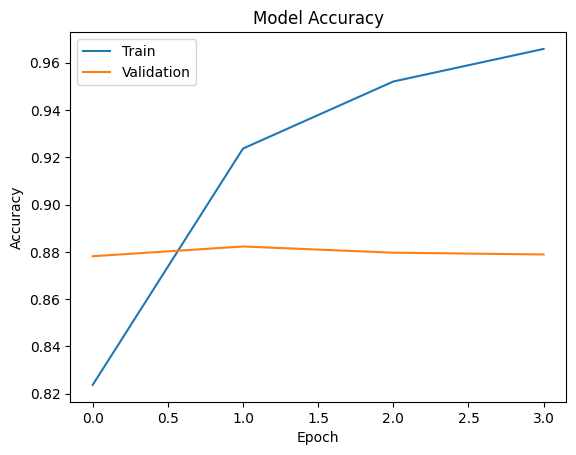

In [34]:
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend(["Train","Validation"])

plt.show()

In [40]:
user_review = input("Enter a movie review: ")

seq = tokenizer.texts_to_sequences([user_review])

pad = pad_sequences(seq, maxlen=max_length)

prediction = model.predict(pad)

score = prediction[0][0]

if score >= 0.5:
    sentiment = "Positive 😊"
    confidence = score
else:
    sentiment = "Negative 😡"
    confidence = 1 - score

print("\nReview:", user_review)
print("Predicted Sentiment:", sentiment)
print("Confidence:", round(confidence,2))

1/1 [==============================] - 0s 20ms/step

Review: This was the worst movie ever
Predicted Sentiment: Negative 😡
Confidence: 0.98
